In [ ]:
# !pip install imgaug timm

# !pip uninstall -y numpy
# !pip install numpy==1.26.4

In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn.functional as F

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
torch.cuda.device_count()

1

In [ ]:
def display_images(image_paths, title, max_images=4):
    plt.figure(figsize=(12, 3))
    for i, image_path in enumerate(image_paths[:max_images]):
        img = plt.imread(image_path)
        plt.subplot(1, max_images, i+1)
        plt.title(title)
        plt.axis('off')
        plt.imshow(img, cmap='gray')

    plt.show()

In [ ]:
categories = ['Train compress', 'Train defocus', 'Train general', 'Train motion', 'Train noise',
              'Val compress', 'Val defocus', 'Val general', 'Val motion', 'Val noise',
              'Test compress', 'Test defocus', 'Test general', 'Test motion', 'Test noise']

for category in categories:
    img_paths = glob.glob(f'/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Datasets/12-01. (1) 영상 품질 저하 요소 분류 실습 (Environmental Degradation 요소 및 tensorRT) - 데이터셋/{category.lower().replace(" ", "/")}/*')
    display_images(img_paths, category)
    print(f'Image count: {len(img_paths)}')

Output hidden; open in https://colab.research.google.com to view.

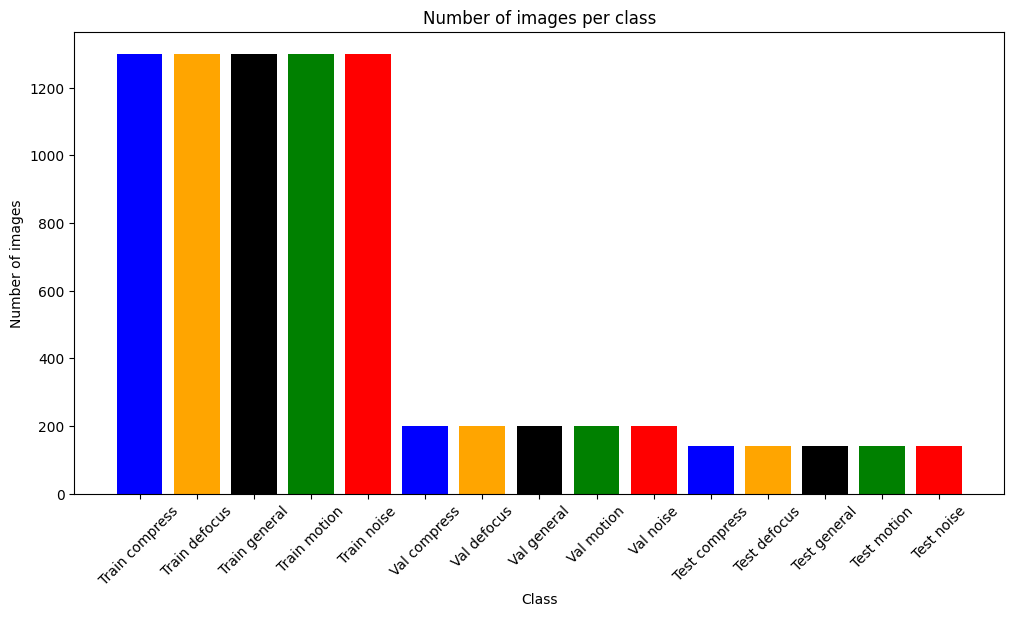

In [ ]:
plt.figure(figsize=(12, 6))
count = [len(glob.glob(f'/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Datasets/12-01. (1) 영상 품질 저하 요소 분류 실습 (Environmental Degradation 요소 및 tensorRT) - 데이터셋/{category.lower().replace(" ", "/")}/*')) for category in categories]
plt.bar(categories, count, color=['blue', 'orange', 'black', 'green', 'red'])
plt.title("Number of images per class")
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.xticks(rotation=45)
plt.show()


In [ ]:
from imgaug import augmenters as iaa
import imgaug as ia

class ImgAugTranform:
    def __init__(self):
        self.aug = iaa.Sequential([
            iaa.Fliplr(0.5),
            iaa.Flipud(0.5),
            iaa.Sometimes(0.2, iaa.Affine(rotate=(-25, 25))),
            iaa.Sometimes(0.2, iaa.Multiply((0.8, 1.2)))
        ])

    def __call__(self, img):
        img = np.array(img)

        return self.aug.augment_image(img)

In [ ]:
class CustomDataset(ImageFolder):
    def __init__(self, root, imgaug=None, transform=None):
        super(CustomDataset, self).__init__(root, transform=transform)

        self.image_transform = imgaug

    def __getitem__(self, index):
        path, target = self.samples[index]

        img = self.loader(path)

        if self.image_transform is not None:
            img = self.image_transform(img)
            img = Image.fromarray(img)

        if self.transform is not None:
            img = self.transform(img)


        return img, target

In [ ]:
from torchvision.transforms.transforms import Normalize
from torchvision import transforms

pytorch_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = CustomDataset('/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Datasets/12-01. (1) 영상 품질 저하 요소 분류 실습 (Environmental Degradation 요소 및 tensorRT) - 데이터셋/train', imgaug=ImgAugTranform(), transform=pytorch_transform)
val_dataset = CustomDataset('/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Datasets/12-01. (1) 영상 품질 저하 요소 분류 실습 (Environmental Degradation 요소 및 tensorRT) - 데이터셋/val', transform=pytorch_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
def show_batch_img(img, labels, class_to_idx, size=(10, 10), mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    idx_to_class = {v:k for k, v in class_to_idx.items()}

    img = img.numpy().transpose((1, 2, 0))
    mean = np.array(mean)
    std = np.array(std)
    img = std*img + mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=size)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    rows = 2
    columns = 4
    for i, label in enumerate(labels[:8]):
        class_name = idx_to_class[label.item()]
        x = (i % columns)*(img.shape[1]//columns) + 100
        y = (i // columns)*(img.shape[0] // rows) + 10
        plt.text(x, y, f'{label.item()}, {class_name}', color='red', fontsize=14)

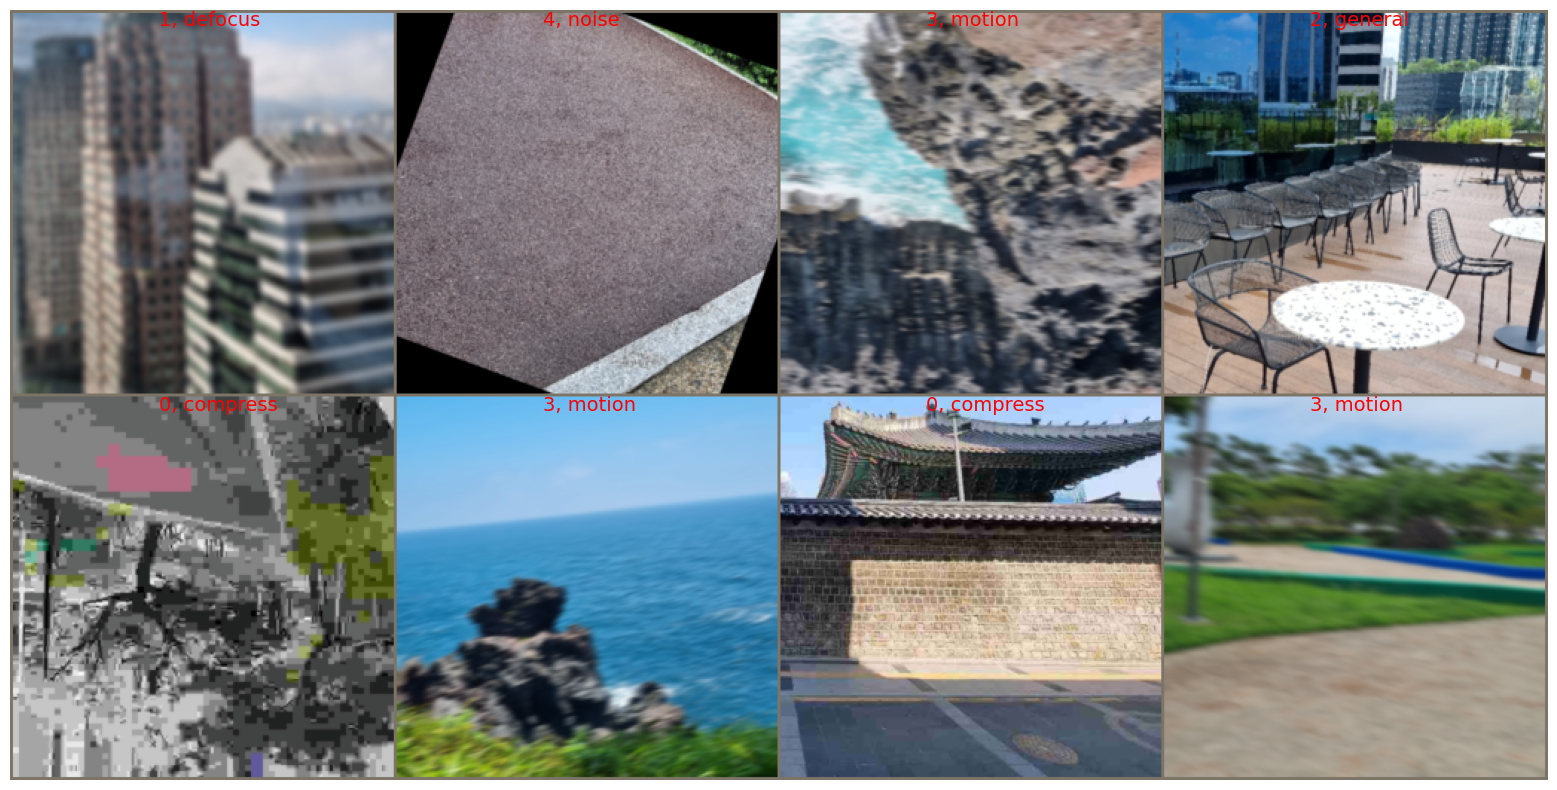

In [ ]:
dataiter = iter(train_loader)
images, label = next(dataiter)

class_to_idx = train_loader.dataset.class_to_idx

show_batch_img(make_grid(images[:8], nrow=4), label, class_to_idx, size=(20, 10))

In [ ]:
print(len(timm.list_models(pretrained=True)))

1691


In [ ]:
swin_model = timm.models.swinv2_base_window8_256(pretrained=True)

In [ ]:
swin_model

SwinTransformerV2(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerV2Stage(
      (downsample): Identity()
      (blocks): ModuleList(
        (0): SwinTransformerV2Block(
          (attn): WindowAttention(
            (cpb_mlp): Sequential(
              (0): Linear(in_features=2, out_features=512, bias=True)
              (1): ReLU(inplace=True)
              (2): Linear(in_features=512, out_features=4, bias=False)
            )
            (qkv): Linear(in_features=128, out_features=384, bias=False)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=128, out_features=128, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (drop_path1): 

In [ ]:
for param in swin_model.parameters():
    param.requires_grad = False

In [ ]:
swin_model.head.fc = nn.Linear(1024, 5)

In [ ]:
for param in swin_model.head.fc.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
swin_model = swin_model.to(device)

In [ ]:
from tqdm import tqdm_notebook as tqdm